In [ ]:
!pip install numpy==2.0.2 tifffile imagecodecs opencv-python matplotlib pandas gdown -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 72.0 MB/s eta 0:00:00


In [ ]:
import cv2
import tifffile
import numpy as np
import matplotlib.pyplot as plt

import glob
import zipfile
import os
import random

import pandas as pd
import gdown

In [ ]:
url = "https://drive.google.com/uc?id=1HJSqARdsbkF1RFEHiFYAtj-JSU2HHjO5"

output = "/content/thermal_images.zip"

gdown.download(url, output, quiet=False)

extract_path = "/content/thermal_images"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset Downloaded and Extracted Successfully")

for root, dirs, files in os.walk(extract_path):

    print(root, "->", len(files), "files")


Downloading...
From (original): https://drive.google.com/uc?id=1HJSqARdsbkF1RFEHiFYAtj-JSU2HHjO5
From (redirected): https://drive.google.com/uc?id=1HJSqARdsbkF1RFEHiFYAtj-JSU2HHjO5&confirm=t&uuid=1c5996ba-3672-46c9-9e1e-2c08d2b879cd
To: /content/thermal_images.zip
100%|██████████| 158M/158M [00:03<00:00, 51.2MB/s]


✅ Dataset Downloaded and Extracted Successfully
/content/thermal_images -> 0 files
/content/thermal_images/thermal_images -> 500 files


In [ ]:
image_paths = glob.glob(
    "/content/thermal_images/**/*.tif",
    recursive=True
)

image_paths += glob.glob(
    "/content/thermal_images/**/*.tiff",
    recursive=True
)

print("✅ Total Images Found:", len(image_paths))

print("\nSample Images:\n")

print(image_paths[:5])

✅ Total Images Found: 500

Sample Images:

['/content/thermal_images/thermal_images/Record_2026-01-05_09-23-00.tiff', '/content/thermal_images/thermal_images/Record_2026-01-05_17-03-00.tiff', '/content/thermal_images/thermal_images/Record_2026-01-05_11-31-00.tiff', '/content/thermal_images/thermal_images/Record_2026-01-05_16-30-00.tiff', '/content/thermal_images/thermal_images/Record_2026-01-05_13-58-00.tiff']


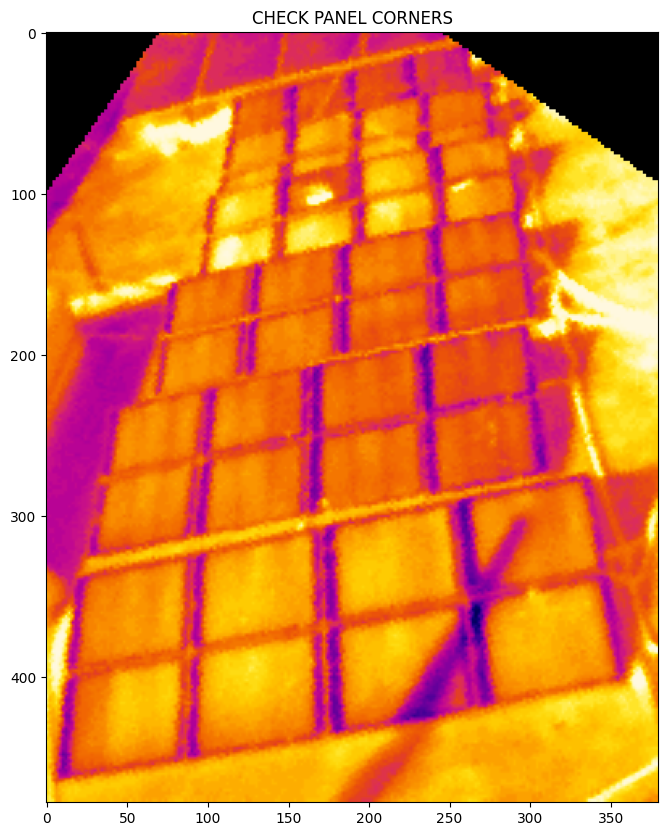

In [ ]:
sample_image = image_paths[0]

image = tifffile.imread(sample_image)

image = cv2.normalize(
    image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

if len(image.shape) == 2:
    display_img = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
else:
    display_img = image.copy()

plt.figure(figsize=(8,10))
plt.imshow(display_img)
plt.title("CHECK PANEL CORNERS")
plt.axis('on')
plt.show()

In [ ]:
panel_polygon = np.array([[
    (115, 35),
    (260, 15),
    (360, 405),
    (15, 460)
]], dtype=np.int32)

In [ ]:
def detect_hotspots(
    image_path,
    panel_polygon,
    hotspot_percentile=99.85,
    min_hotspot_area=40
):

    import cv2
    import tifffile
    import numpy as np
    import matplotlib.pyplot as plt


    image = tifffile.imread(image_path)

    image = cv2.normalize(
        image,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)


    if len(image.shape) == 2:

        gray = image

        original = cv2.cvtColor(
            image,
            cv2.COLOR_GRAY2RGB
        )

    else:

        original = image.copy()

        gray = cv2.cvtColor(
            original,
            cv2.COLOR_RGB2GRAY
        )


    mask = np.zeros_like(gray)

    cv2.fillPoly(
        mask,
        panel_polygon,
        255
    )



    inner_mask = cv2.erode(
        mask,
        np.ones((30,30), np.uint8),
        iterations=1
    )


    gap_mask = inner_mask.copy()

    h, w = gray.shape

    separator_lines = [
        int(h * 0.33),
        int(h * 0.66)
    ]

    for y in separator_lines:

        cv2.rectangle(
            gap_mask,
            (0, y-12),
            (w, y+12),
            0,
            -1
        )

    inner_mask = gap_mask

    exclusion_quad = np.array(
        [[(22,329),(332,269),(332,277),(22,337)]],
        dtype=np.int32
    )

    cv2.fillPoly(
        inner_mask,
        exclusion_quad,
        0
    )



    panel_pixels = gray[inner_mask > 0]

    threshold_value = np.percentile(
        panel_pixels,
        hotspot_percentile
    )

    hotspot_mask = np.zeros_like(gray)

    hotspot_mask[
        (gray >= threshold_value) &
        (inner_mask > 0)
    ] = 255



    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (9,9)
    )

    hotspot_mask = cv2.morphologyEx(
        hotspot_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    hotspot_mask = cv2.dilate(
        hotspot_mask,
        kernel,
        iterations=1
    )



    contours, _ = cv2.findContours(
        hotspot_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    output = original.copy()

    hotspot_count = 0

    for cnt in contours:

        area = cv2.contourArea(cnt)


        if area < min_hotspot_area:
            continue

        x,y,w,h = cv2.boundingRect(cnt)


        aspect_ratio = max(w,h) / (min(w,h) + 1)

        if aspect_ratio > 3:
            continue

        hotspot_count += 1


        cv2.rectangle(
            output,
            (x,y),
            (x+w,y+h),
            (0,255,0),
            2
        )


        cv2.circle(
            output,
            (x+w//2, y+h//2),
            5,
            (255,0,0),
            -1
        )


    cv2.polylines(
        output,
        panel_polygon,
        True,
        (255,0,0),
        3
    )


    plt.figure(figsize=(20,6))

    plt.subplot(1,3,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(hotspot_mask, cmap='gray')
    plt.title("Detected Hotspots")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(output)
    plt.title(f"Hotspots Found: {hotspot_count}")
    plt.axis('off')

    plt.show()


    print(f"✅ Total Hotspots Detected: {hotspot_count}")

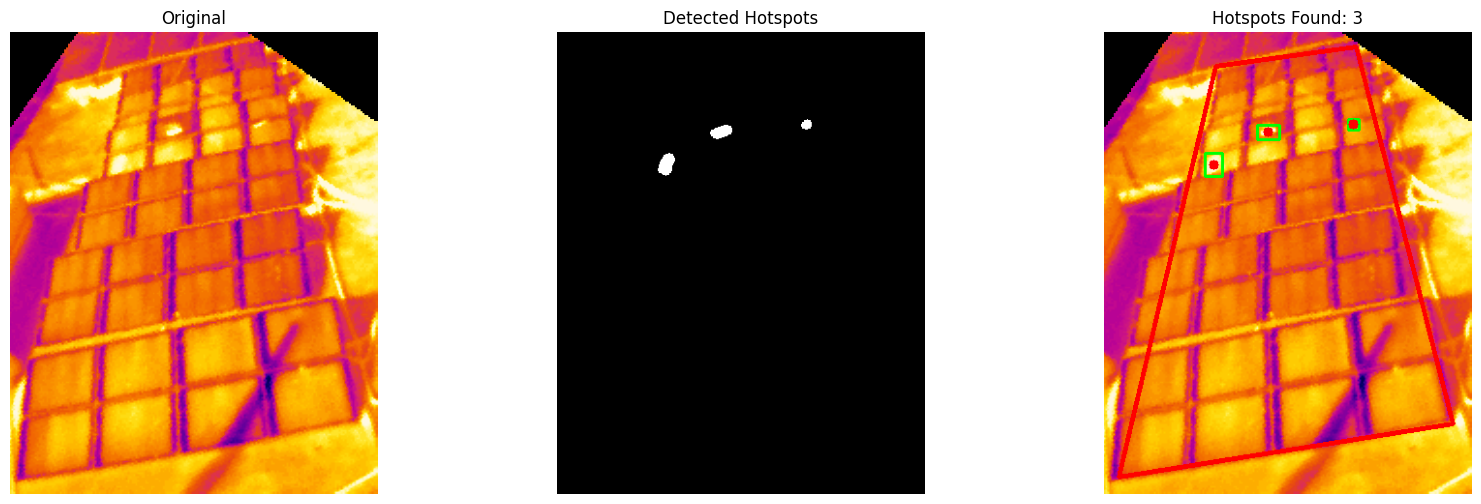

✅ Total Hotspots Detected: 3


In [ ]:
detect_hotspots(
    image_paths[0],
    panel_polygon,
    hotspot_percentile=99.85,
    min_hotspot_area=40
)



Random Selected Image 1
File Name: Record_2026-01-05_16-13-00.tiff


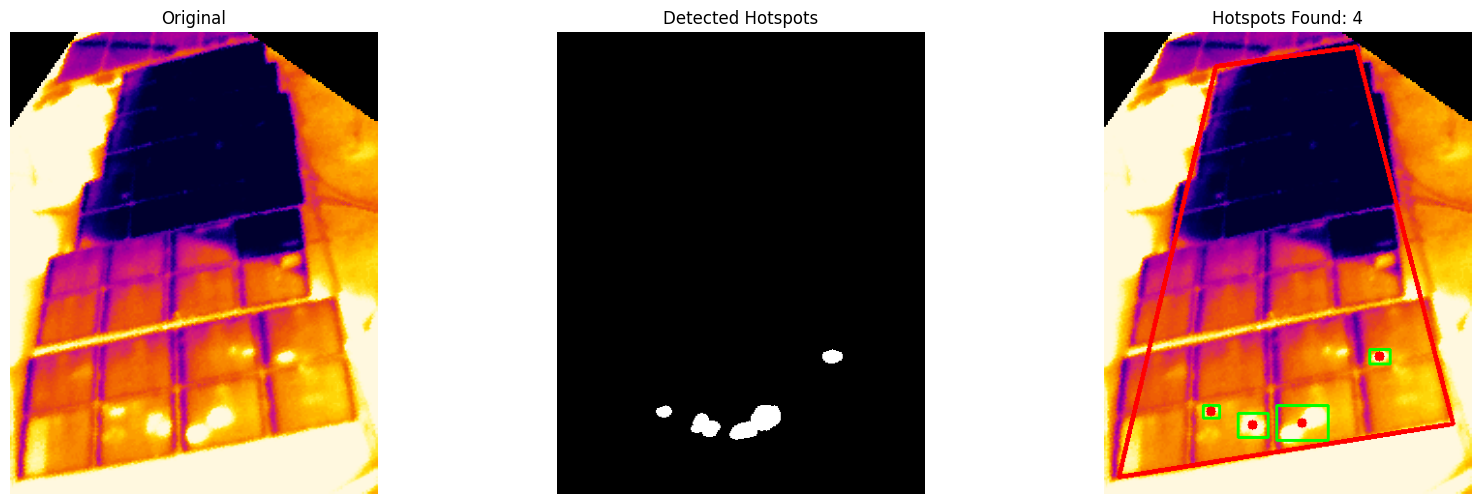

✅ Total Hotspots Detected: 4

Random Selected Image 2
File Name: Record_2026-01-05_10-19-00.tiff


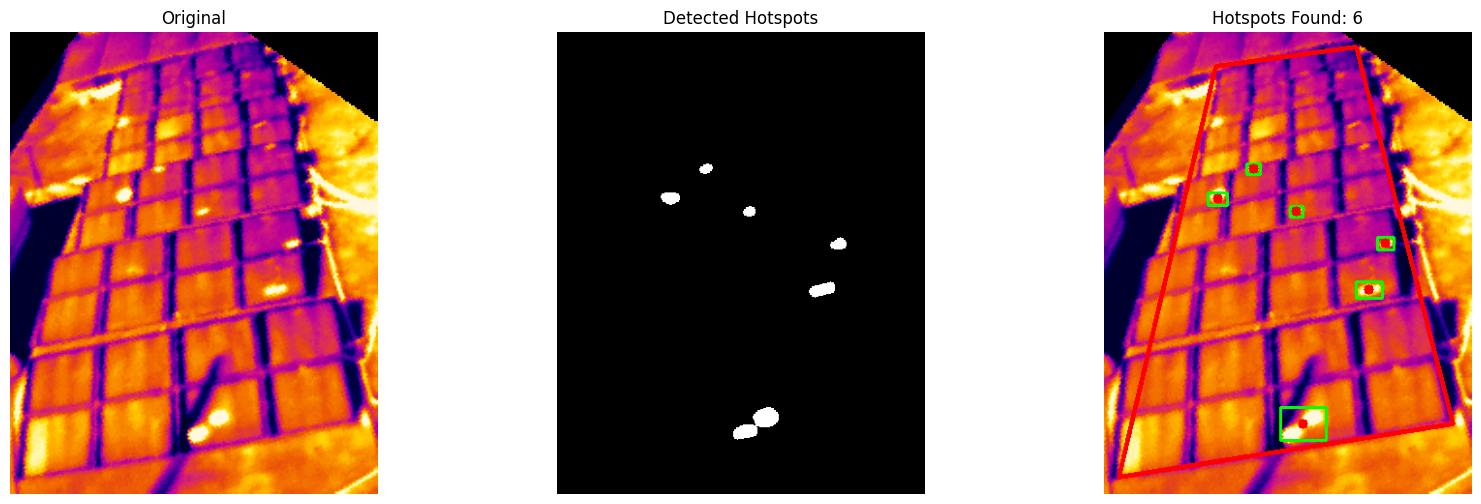

✅ Total Hotspots Detected: 6

Random Selected Image 3
File Name: Record_2026-01-05_12-33-00.tiff


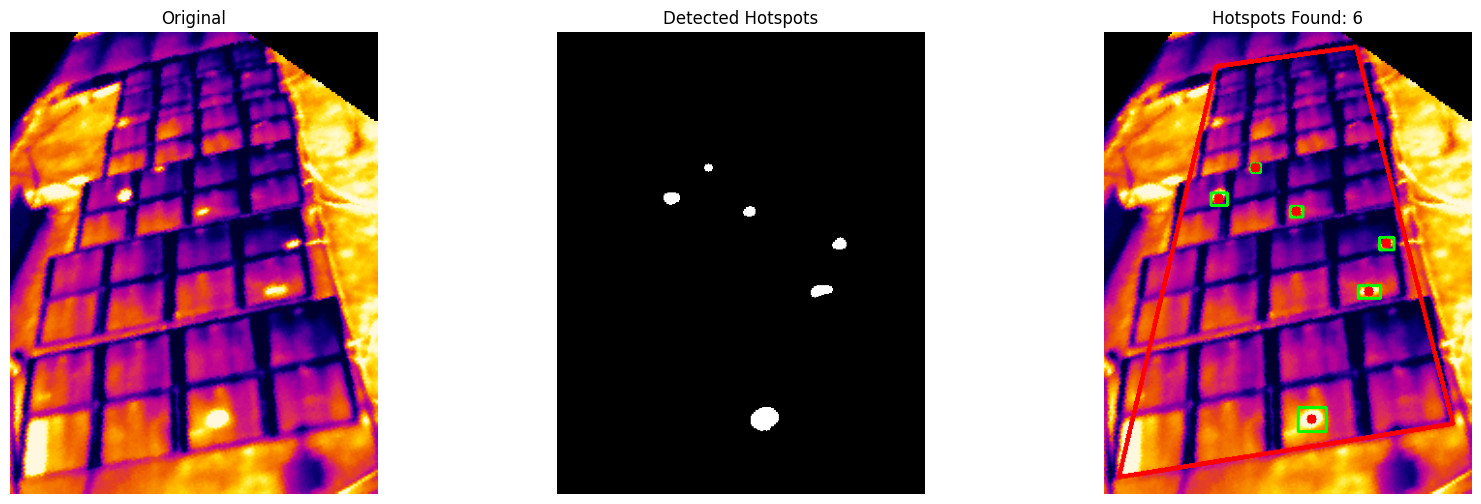

✅ Total Hotspots Detected: 6

Random Selected Image 4
File Name: Record_2026-01-05_10-08-00.tiff


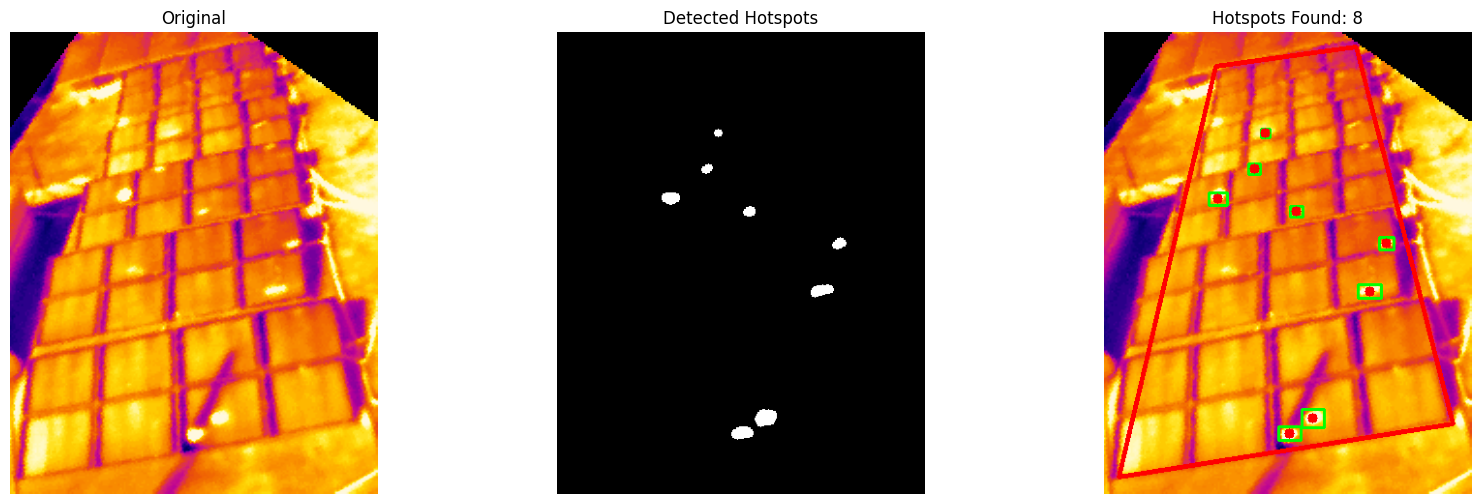

✅ Total Hotspots Detected: 8

Random Selected Image 5
File Name: Record_2026-01-05_10-40-00.tiff


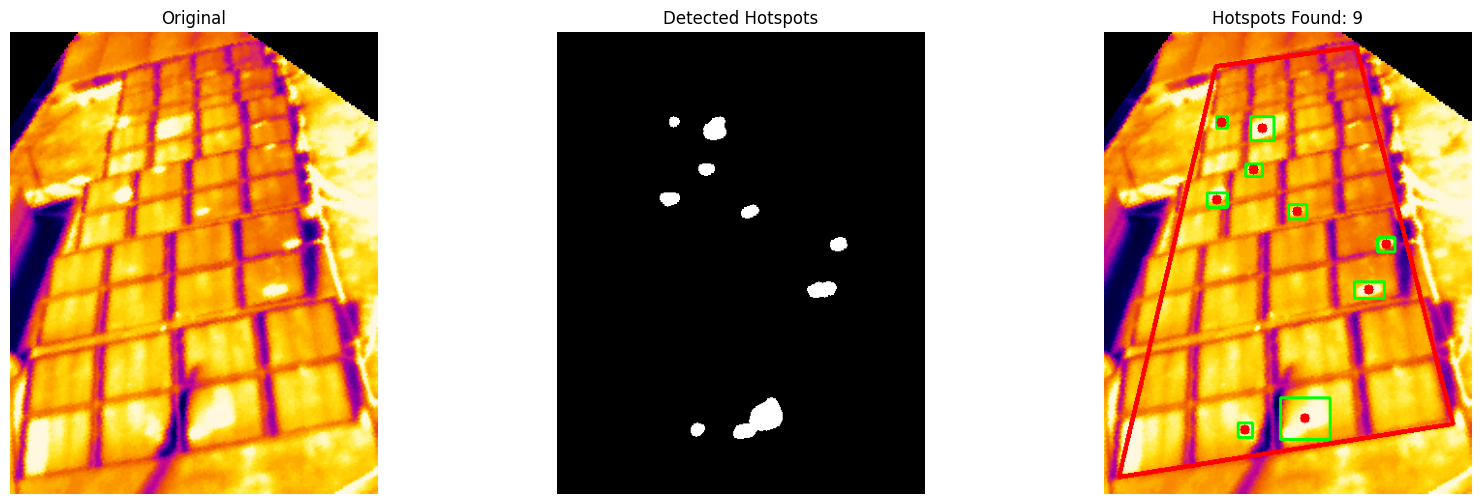

✅ Total Hotspots Detected: 9


In [ ]:
import os
import random


target_times = [

    "09-14",
    "12-33",
    "17-09",
    "14-45",
    "10-40",
    "13-29",
    "13-00",
    "11-35",
    "11-25",
    "10-08",
    "11-43",
    "13-31",
    "12-36",
    "10-19",
    "10-14",
    "11-16",
    "13-16",
    "11-11",
    "11-03",
    "13-19",
    "13-38",
    "16-44"

]


selected_image_paths = [

    path for path in image_paths

    if any(
        t in os.path.basename(path)
        for t in target_times
    )
]


random_5_images = random.sample(
    selected_image_paths,
    5
)


for idx, img_path in enumerate(random_5_images):

    print("\n===================================")
    print(f"Random Selected Image {idx+1}")

    print("File Name:", os.path.basename(img_path))

    detect_hotspots(
        img_path,
        panel_polygon,
        hotspot_percentile=99.85,
        min_hotspot_area=40
    )